# 实验：用于手写数字识别的神经网络（二分类）

在本练习中，你将使用神经网络来识别手写数字0和1。


# 目录
- [ 1 - 包 ](#1)
- [ 2 - 神经网络](#2)
  - [ 2.1 问题描述](#2.1)
  - [ 2.2 数据集](#2.2)
  - [ 2.3 模型表示](#2.3)
  - [ 2.4 Tensorflow模型实现](#2.4)
    - [ 练习 1](#ex01)
  - [ 2.5 NumPy模型实现（NumPy中的前向传播）](#2.5)
    - [ 练习 2](#ex02)
  - [ 2.6 向量化NumPy模型实现（可选）](#2.6)
    - [ 练习 3](#ex03)
  - [ 2.7 恭喜！](#2.7)
  - [ 2.8 NumPy广播教程（可选）](#2.8)


_**注意：** 为了防止自动评分器出错，不允许编辑或删除本notebook中的非评分单元。也请不要添加任何新单元。 
**一旦你通过了本作业**并想尝试任何非评分代码，你可以按照本notebook底部的说明操作。_

<a name="1"></a>
## 1 - 包 

首先，让我们运行下面的单元来导入你在本作业中需要的所有包。
- [numpy](https://numpy.org/) 是Python科学计算的基础包。
- [matplotlib](http://matplotlib.org) 是一个流行的Python绘图库。
- [tensorflow](https://www.tensorflow.org/) 是一个流行的机器学习平台。

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from autils import *
%matplotlib inline

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

I0000 00:00:1781367694.737723  151765 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781367694.797182  151765 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781367696.704286  151765 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


**Tensorflow和Keras**  
Tensorflow是Google开发的机器学习包。2019年，Google将Keras集成到Tensorflow中并发布了Tensorflow 2.0。Keras是由François Chollet独立开发的框架，为Tensorflow创建了一个简单的、以层为中心的接口。本课程将使用Keras接口。

<a name="2"></a>
## 2 - 神经网络

在课程1中，你实现了逻辑回归。这被扩展为使用多项式回归来处理非线性边界。对于更复杂的场景，如图像识别，神经网络更受青睐。

<a name="2.1"></a>
### 2.1 问题描述

在本练习中，你将使用神经网络来识别两个手写数字，0和1。这是一个二分类任务。自动手写数字识别如今被广泛使用——从识别信封上的邮政编码到识别银行支票上的金额。你将在未来的作业中扩展此网络以识别所有10个数字（0-9）。 

本练习将向你展示如何将你学到的方法用于此分类任务。

<a name="2.2"></a>
### 2.2 数据集

你将首先加载本任务的数据集。 
- 下面显示的`load_data()`函数将数据加载到变量`X`和`y`中


- 数据集包含1000个手写数字的训练样本$^1$，这里仅限于0和1。  

    - 每个训练样本是一个20像素×20像素的灰度图像。 
        - 每个像素由一个浮点数表示，表示该位置的灰度强度。 
        - 20×20的像素网格被"展开"成一个400维向量。 
        - 每个训练样本成为数据矩阵`X`中的一行。 
        - 这给了我们一个1000×400的矩阵`X`，其中每一行是一个手写数字图像的训练样本。

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$ 

- 训练集的第二部分是一个1000×1维向量`y`，包含训练集的标签
    - 如果图像是数字`0`，则`y = 0`；如果图像是数字`1`，则`y = 1`。

$^1$<sub> 这是MNIST手写数字数据集的子集 (http://yann.lecun.com/exdb/mnist/)</sub>

In [2]:
# 加载数据集
X, y = load_data()

<a name="toc_89367_2.2.1"></a>
#### 2.2.1 查看变量
让我们更熟悉你的数据集。  
- 一个好的起点是打印出每个变量，看看它包含什么。

下面的代码打印变量`X`和`y`的元素。

In [3]:
print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+

In [4]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  1


<a name="toc_89367_2.2.2"></a>
#### 2.2.2 检查变量的维度

另一种熟悉数据的方法是查看其维度。请打印`X`和`y`的形状，看看你的数据集中有多少训练样本。

In [5]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (1000, 400)
The shape of y is: (1000, 1)


<a name="toc_89367_2.2.3"></a>
#### 2.2.3 数据可视化

你将首先可视化训练集的一个子集。 
- 在下面的单元中，代码从`X`中随机选择64行，将每行映射回20像素×20像素的灰度图像，并一起显示这些图像。 
- 每个图像的标签显示在图像上方

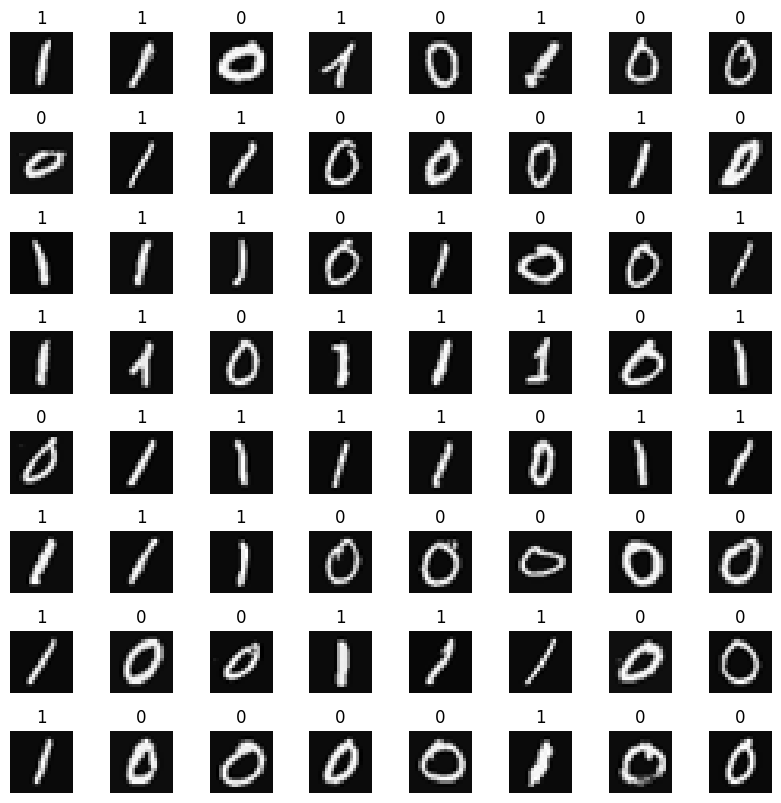

In [6]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # 选择随机索引
    random_index = np.random.randint(m)
    
    # 选择对应随机索引的行并
    # 重塑图像
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # 显示图像
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # 在图像上方显示标签
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

<a name="2.3"></a>
### 2.3 模型表示

你将在本作业中使用的神经网络如下图所示。 
- 它有三个带有sigmoid激活函数的密集层。
    - 回想一下，我们的输入是数字图像的像素值。
    - 由于图像大小为$20\times20$，这给了我们$400$个输入  
    
<img src="images/C2_W1_Assign1.PNG" width="500" height="400">

- 参数的维度是为具有$25$个单元的第1层、$15$个单元的第2层和$1$个输出单元的第3层的神经网络而设定的。 

    - 回想一下，这些参数的维度确定如下：
        - 如果网络某层有$s_{in}$个单元，下一层有$s_{out}$个单元，则 
            - $W$的维度为$s_{in} \times s_{out}$。
            - $b$将是一个具有$s_{out}$个元素的向量
  
    - 因此，`W`和`b`的形状为 
        - 第1层：`W1`的形状为(400, 25)，`b1`的形状为(25,)
        - 第2层：`W2`的形状为(25, 15)，`b2`的形状为：(15,)
        - 第3层：`W3`的形状为(15, 1)，`b3`的形状为：(1,)
>**注意：** 偏置向量`b`可以表示为一维(n,)或二维(1,n)数组。Tensorflow使用一维表示，本实验将保持这一惯例。 
               

<a name="2.4"></a>
### 2.4 Tensorflow模型实现


Tensorflow模型是逐层构建的。层的输入维度（上面的$s_{in}$）会自动计算。你指定层的*输出维度*，这决定了下一层的输入维度。第一层的输入维度由下面`model.fit`语句中指定的输入数据大小决定。 
>**注意：** 也可以添加一个指定第一层输入维度的输入层。例如：  
`tf.keras.Input(shape=(400,)),    #指定输入形状`  
我们将在这里包含它以说明一些模型大小调整。

<a name="ex01"></a>
### 练习 1

下面，使用Keras [Sequential模型](https://keras.io/guides/sequential_model/)和带有sigmoid激活函数的[Dense层](https://keras.io/api/layers/core_layers/dense/)来构建上面描述的网络。

In [7]:
# UNQ_C1
# 评分单元：Sequential模型

model = Sequential(
    [               
        tf.keras.Input(shape=(400,)),    #指定输入大小
        ### 开始代码 ### 
        Dense(units = 25, activation = 'sigmoid', name = 'layer1'),
        Dense(units = 15, activation = 'sigmoid', name = 'layer2'),
        Dense(units = 1, activation = 'sigmoid', name = 'layer3')
        ### 结束代码 ### 
    ], name = "my_model" 
)                            


W0000 00:00:1781367701.305411  151765 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,431 (40.75 KB)

 Trainable params: 10,431 (40.75 KB)

 Non-trainable params: 0 (0.00 B)

<details>
  <summary><font size="3" color="darkgreen"><b>预期输出（点击展开）</b></font></summary>
`model.summary()`函数显示了模型的有用摘要。因为我们指定了输入层大小，所以权重和偏置数组的形状被确定，并且可以显示每层的参数总数。注意，层的名称可能不同，因为它们是自动生成的。  
    
    
```
Model: "my_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
dense (Dense)                (None, 25)                10025     
_________________________________________________________________
dense_1 (Dense)              (None, 15)                390       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 16        
=================================================================
Total params: 10,431
Trainable params: 10,431
Non-trainable params: 0
_________________________________________________________________
```

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
As described in the lecture:
    
```python
model = Sequential(                      
    [                                   
        tf.keras.Input(shape=(400,)),    # 指定输入大小（可选）
        Dense(25, activation='sigmoid'), 
        Dense(15, activation='sigmoid'), 
        Dense(1,  activation='sigmoid')  
    ], name = "my_model"                                    
)                                       
``` 

In [9]:
# UNIT TESTS
from public_tests import *

test_c1(model)

所有测试通过!


摘要中显示的参数计数对应于权重和偏置数组中的元素数量，如下所示。

In [10]:
L1_num_params = 400 * 25 + 25  # W1参数 + b1参数
L2_num_params = 25 * 15 + 15   # W2参数 + b2参数
L3_num_params = 15 * 1 + 1     # W3参数 + b3参数
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params, ",  L3 params = ", L3_num_params )

L1 params =  10025 , L2 params =  390 ,  L3 params =  16


我们可以通过首先使用`model.layers`提取层，然后使用`layerx.get_weights()`提取权重来检查模型的细节，如下所示。

In [11]:
[layer1, layer2, layer3] = model.layers

In [12]:
#### 检查权重形状
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 1), b3 shape = (1,)


**Expected Output**
```
W1 shape = (400, 25), b1 shape = (25,)  
W2 shape = (25, 15), b2 shape = (15,)  
W3 shape = (15, 1), b3 shape = (1,)
```

`xx.get_weights`返回NumPy数组。也可以直接以张量形式访问权重。注意最后一层张量的形状。

In [13]:
print(model.layers[2].weights)

[<Variable path=my_model/layer3/kernel, shape=(15, 1), dtype=float32, value=[[ 0.58841807]
 [ 0.1863473 ]
 [ 0.4845248 ]
 [-0.4584096 ]
 [-0.3972311 ]
 [-0.44998652]
 [-0.52948827]
 [-0.57798177]
 [-0.28913155]
 [-0.26785308]
 [ 0.02887213]
 [ 0.30573803]
 [ 0.02131963]
 [ 0.15410429]
 [-0.27972794]]>, <Variable path=my_model/layer3/bias, shape=(1,), dtype=float32, value=[0.]>]


以下代码将定义一个损失函数并运行梯度下降来将模型的权重拟合到训练数据。这将在下周更详细地解释。

In [14]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
)

model.fit(
    X,y,
    epochs=20
)

Epoch 1/20


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6400  
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4702
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3268
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2255
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1635
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1255
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1001
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0823
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0694
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0595
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0519
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0458
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0410
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0371
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0337
Epoch 16/20
32/32 ━━━━━━━━━━

要在样本上运行模型进行预测，请使用[Keras `predict`](https://www.tensorflow.org/api_docs/python/tf/keras/Model)。`predict`的输入是数组，因此单个样本被重塑为二维。

In [15]:
prediction = model.predict(X[0].reshape(1,400))  # a zero
print(f" predicting a zero: {prediction}")
prediction = model.predict(X[500].reshape(1,400))  # a one
print(f" predicting a one:  {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
 predicting a zero: [[0.01366672]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
 predicting a one:  [[0.9785772]]


模型的输出被解释为概率。在上面的第一个例子中，输入是0。模型预测输入为1的概率几乎为零。 
在第二个例子中，输入是1。模型预测输入为1的概率几乎为一。
与逻辑回归的情况一样，将概率与阈值进行比较以做出最终预测。

In [16]:
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print(f"prediction after threshold: {yhat}")

prediction after threshold: 1


让我们将预测与64个随机数字样本的标签进行比较。这需要一些时间来运行。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


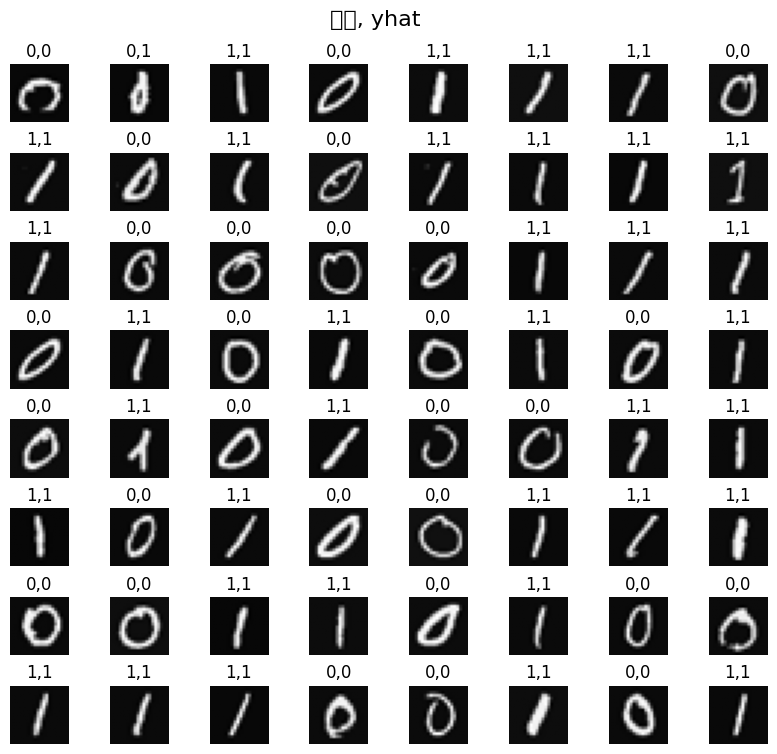

In [17]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# 你不需要修改此单元中的任何内容

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[左, 下, 右, 上]

for i,ax in enumerate(axes.flat):
    # 选择随机索引
    random_index = np.random.randint(m)
    
    # 选择对应随机索引的行并
    # 重塑图像
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # 显示图像
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # 使用神经网络进行预测
    prediction = model.predict(X[random_index].reshape(1,400))
    if prediction >= 0.5:
        yhat = 1
    else:
        yhat = 0
    
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}")
    ax.set_axis_off()
fig.suptitle("标签, yhat", fontsize=16)
plt.show()

<a name="2.5"></a>
### 2.5 NumPy模型实现（NumPy中的前向传播）
如讲座中所述，可以使用NumPy构建自己的密集层。然后可以利用它来构建多层神经网络。 

<img src="images/C2_W1_dense2.PNG" width="600" height="450">


<a name="ex02"></a>
### 练习 2

下面，构建一个密集层子程序。讲座中的例子使用for循环访问层中的每个单元（`j`），并对该单元的权重（`W[:,j]`）执行点积，并对单元的偏置（`b[j]`）求和以形成`z`。然后对该结果应用激活函数`g(z)`。本节将不使用可选讲座中描述的一些矩阵操作。这些将在后面的部分中探讨。

In [18]:
# UNQ_C2
# 评分函数: my_dense

def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
### START CODE HERE ### 
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):
        w = W[:,j]
        z_j = np.dot(w, a_in) + b[j]
        a_out[j] = g(z_j)
### END CODE HERE ### 
    return(a_out)

In [19]:
# 快速检查
x_tst = 0.1*np.arange(1,3,1).reshape(2,)  # (1 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(3,)  # (3 features)
A_tst = my_dense(x_tst, W_tst, b_tst, sigmoid)
print(A_tst)

[0.54735762 0.57932425 0.61063923]


**Expected Output**
```
[0.54735762 0.57932425 0.61063923]
```

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
As described in the lecture:
    
```python
def my_dense(a_in, W, b, g):
    """
    计算密集层
    参数:
      a_in (ndarray (n, )) : 数据，1个样本 
      W    (ndarray (n,j)) : 权重矩阵，每个单元n个特征，j个单元
      b    (ndarray (j, )) : 偏置向量，j个单元  
      g    激活函数（例如sigmoid, relu等）
    返回
      a_out (ndarray (j,))  : j个单元
    """
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):             
        w =                            # 选择第j个单元的权重。这些在W的第j列
        z =                            # w和a_in的点积 + b
        a_out[j] =                     # 对z应用激活函数
    return(a_out)
```
   
    
<details>
  <summary><font size="3" color="darkgreen"><b>Click for more hints</b></font></summary>

    
```python
def my_dense(a_in, W, b, g):
    """
    计算密集层
    参数:
      a_in (ndarray (n, )) : 数据，1个样本 
      W    (ndarray (n,j)) : 权重矩阵，每个单元n个特征，j个单元
      b    (ndarray (j, )) : 偏置向量，j个单元  
      g    激活函数（例如sigmoid, relu等）
    返回
      a_out (ndarray (j,))  : j个单元
    """
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):             
        w = W[:,j]                     
        z = np.dot(w, a_in) + b[j]     
        a_out[j] = g(z)                
    return(a_out)
``` 

In [20]:
# UNIT TESTS

test_c2(my_dense)

所有测试通过!


以下单元使用上面的`my_dense`子程序构建了一个三层神经网络。

In [27]:
def my_sequential(x, W1, b1, W2, b2, W3, b3):
    a1 = my_dense(x,  W1, b1, sigmoid)
    a2 = my_dense(a1, W2, b2, sigmoid)
    a3 = my_dense(a2, W3, b3, sigmoid)
    return(a3.flatten()[0])

我们可以从Tensorflow复制训练好的权重和偏置。

In [22]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

In [23]:
# 进行预测
prediction = my_sequential(X[0], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print( "yhat = ", yhat, " label= ", y[0,0])
prediction = my_sequential(X[500], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print( "yhat = ", yhat, " label= ", y[500,0])

yhat =  0  label=  0
yhat =  1  label=  1


运行以下单元以查看Numpy模型和Tensorflow模型的预测。这需要一些时间来运行。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


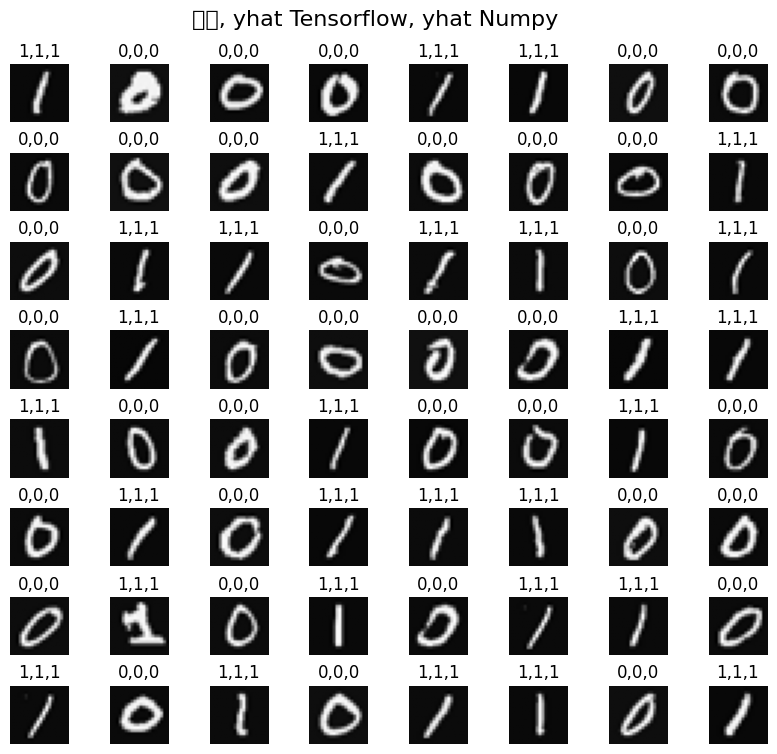

In [29]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# 你不需要修改此单元中的任何内容

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[左, 下, 右, 上]

for i,ax in enumerate(axes.flat):
    # 选择随机索引
    random_index = np.random.randint(m)
    
    # 选择对应随机索引的行并
    # 重塑图像
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # 显示图像
    ax.imshow(X_random_reshaped, cmap='gray')

    # 使用NumPy实现的神经网络进行预测
    my_prediction = my_sequential(X[random_index], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
    my_yhat = int(np.asarray(my_prediction >= 0.5).flatten()[0])

    # 使用Tensorflow实现的神经网络进行预测
    tf_prediction = model.predict(X[random_index].reshape(1,400))
    tf_yhat = int(np.asarray(tf_prediction >= 0.5).flatten()[0])
    
    # 在图像上方显示标签
    ax.set_title(f"{y[random_index,0]},{tf_yhat},{my_yhat}")
    ax.set_axis_off() 
fig.suptitle("标签, yhat Tensorflow, yhat Numpy", fontsize=16)
plt.show()

<a name="2.6"></a>
### 2.6 向量化NumPy模型实现（可选）
可选讲座描述了可用于加速计算的向量和矩阵操作。
下面描述了一个层操作，该操作在给定输入样本上计算层中所有单元的输出：

<img src="images/C2_W1_VectorMatrix.PNG" width="600" height="450">

我们可以使用上面的样本`X`和`W1`、`b1`参数来演示。我们使用`np.matmul`来执行矩阵乘法。注意，x和W的维度必须兼容，如上图所示。

In [ ]:
x = X[0].reshape(-1,1)         # column vector (400,1)
z1 = np.matmul(x.T,W1) + b1    # (1,400)(400,25) = (1,25)
a1 = sigmoid(z1)
print(a1.shape)

(1, 25)


你可以更进一步，在一个矩阵-矩阵操作中计算所有样本的所有单元。

<img src="images/C2_W1_MatrixMatrix.PNG" width="600" height="450">
完整操作是$\mathbf{Z}=\mathbf{XW}+\mathbf{b}$。这将利用NumPy广播将$\mathbf{b}$扩展到$m$行。如果你不熟悉这个，notebook末尾提供了一个简短的教程。

<a name="ex03"></a>
### 练习 3

下面，编写一个新的`my_dense_v`子程序，该程序对样本矩阵执行层计算。这将使用`np.matmul()`。

_**注意**：此函数不评分，因为它在关于向量化的可选讲座中讨论过。如果你没有看过这些讲座，请随意点击预期代码下方的提示来查看代码。你也可以即使在这里留空答案也提交notebook。_

In [ ]:
# UNQ_C3
# 非评分函数: my_dense_v

def my_dense_v(A_in, W, b, g):
    """
    计算密集层
    参数:
      A_in (ndarray (m,n)) : 数据，m个样本，每个样本n个特征
      W    (ndarray (n,j)) : 权重矩阵，每个单元n个特征，j个单元
      b    (ndarray (1,j)) : 偏置向量，j个单元  
      g    激活函数（例如sigmoid, relu等）
    返回
      A_out (tf.Tensor 或 ndarray (m,j)) : m个样本，j个单元
    """
### 开始代码 ### 
    z = np.matmul(A_in, W) + b
    A_out = g(z)
### 结束代码 ### 
    return(A_out)

In [ ]:
X_tst = 0.1*np.arange(1,9,1).reshape(4,2) # (4 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(1,3) # (1,3 features)
A_tst = my_dense_v(X_tst, W_tst, b_tst, sigmoid)
print(A_tst)

[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]]


**预期输出**

```
[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]]
 ```

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    在矩阵形式中，这可以用一两行代码编写。 
    
       Z = np.matmul of A_in and W plus b    
       A_out is g(Z)  
<details>
  <summary><font size="3" color="darkgreen"><b>Click for code</b></font></summary>

```python
def my_dense_v(A_in, W, b, g):
    """
    计算密集层
    参数:
      A_in (ndarray (m,n)) : 数据，m个样本，每个样本n个特征
      W    (ndarray (n,j)) : 权重矩阵，每个单元n个特征，j个单元
      b    (ndarray (j,1)) : 偏置向量，j个单元  
      g    激活函数（例如sigmoid, relu等）
    返回
      A_out (ndarray (m,j)) : m个样本，j个单元
    """
    Z = np.matmul(A_in,W) + b    
    A_out = g(Z)                 
    return(A_out)
```


In [ ]:
# UNIT TESTS

test_c3(my_dense_v)

All tests passed!


以下单元使用上面的`my_dense_v`子程序构建了一个三层神经网络。

In [ ]:
def my_sequential_v(X, W1, b1, W2, b2, W3, b3):
    A1 = my_dense_v(X,  W1, b1, sigmoid)
    A2 = my_dense_v(A1, W2, b2, sigmoid)
    A3 = my_dense_v(A2, W3, b3, sigmoid)
    return(A3)

我们可以再次从Tensorflow复制训练好的权重和偏置。

In [ ]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

让我们用新模型进行预测。这将*一次性对所有样本*进行预测。注意输出的形状。

In [ ]:
Prediction = my_sequential_v(X, W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
Prediction.shape

(1000, 1)

我们将像之前一样应用0.5的阈值，但这次是对所有预测一次性进行。

In [ ]:
Yhat = (Prediction >= 0.5).astype(int)
print("predict a zero: ",Yhat[0], "predict a one: ", Yhat[500])

predict a zero:  [0] predict a one:  [1]


运行以下单元以查看预测。这将使用我们刚刚计算的预测。这需要一些时间来运行。

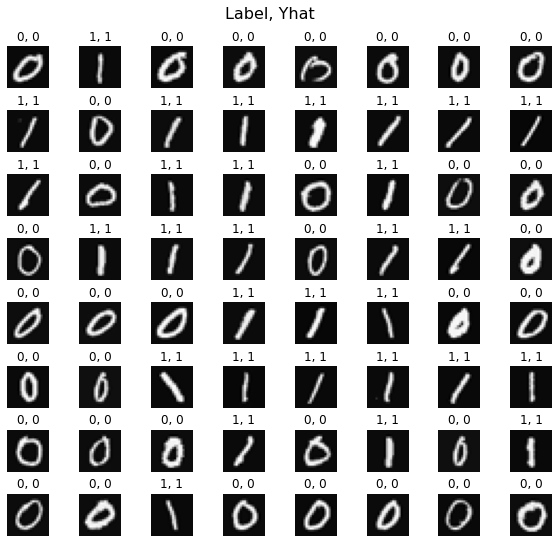

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i, ax in enumerate(axes.flat):
    # 选择随机索引
    random_index = np.random.randint(m)
    
    # 选择对应随机索引的行并
    # 重塑图像
    X_random_reshaped = X[random_index].reshape((20, 20)).T
    
    # 显示图像
    ax.imshow(X_random_reshaped, cmap='gray')
   
    # 在图像上方显示标签
    ax.set_title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
    ax.set_axis_off() 
fig.suptitle("标签, Yhat", fontsize=16)
plt.show()

你可以看到其中一个错误分类的图像是什么样的。

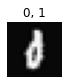

In [ ]:
fig = plt.figure(figsize=(1, 1))
errors = np.where(y != Yhat)
random_index = errors[0][0]
X_random_reshaped = X[random_index].reshape((20, 20)).T
plt.imshow(X_random_reshaped, cmap='gray')
plt.title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
plt.axis('off')
plt.show()

<a name="2.7"></a>
### 2.7 恭喜！
你已经成功构建并使用了一个神经网络。

<a name="2.8"></a>
### 2.8 NumPy广播教程（可选）


在最后一个例子中，$\mathbf{Z}=\mathbf{XW} + \mathbf{b}$利用NumPy广播来扩展向量$\mathbf{b}$。如果你不熟悉NumPy广播，这里提供了一个简短的教程。

$\mathbf{XW}$是一个矩阵-矩阵操作，维度为$(m,j_1)(j_1,j_2)$，结果是一个维度为$(m,j_2)$的矩阵。我们向其添加一个维度为$(1,j_2)$的向量$\mathbf{b}$。$\mathbf{b}$必须被扩展为$(m,j_2)$矩阵，这样逐元素操作才有意义。NumPy广播为你完成了这个扩展。

广播适用于逐元素操作。  
其基本操作是通过复制元素来'拉伸'较小的维度，以匹配较大的维度。

更[具体地说](https://NumPy.org/doc/stable/user/basics.broadcasting.html)： 
当对两个数组进行操作时，NumPy逐元素比较它们的形状。它从尾部（即最右边）的维度开始，向左工作。两个维度在以下情况下是兼容的：
- 它们相等，或者
- 其中一个为1   

如果不满足这些条件，将抛出ValueError: operands could not be broadcast together异常，表明数组的形状不兼容。结果数组的大小是输入中每个轴上不为1的大小。

以下是一些例子：

<figure>
    <center> <img src="./images/C2_W1_Assign1_BroadcastIndexes.PNG"  alt='missing' width="400"  ><center/>
    <figcaption>计算广播结果形状</figcaption>
<figure/>

下面的图形描述了维度的扩展。注意下面的红色文本：

<figure>
    <center> <img src="./images/C2_W1_Assign1_Broadcasting.gif"  alt='missing' width="600"  ><center/>
    <figcaption>广播概念性地扩展参数以匹配逐元素操作</figcaption>
<figure/>

上图显示了NumPy在最终操作之前扩展参数以进行匹配。请注意，这是一个概念性描述。NumPy操作的实际机制会选择最高效的实现。

对于以下每个示例，在运行示例之前尝试猜测结果的大小。

In [ ]:
a = np.array([1,2,3]).reshape(-1,1)  #(3,1)
b = 5
print(f"(a + b).shape: {(a + b).shape}, \na + b = \n{a + b}")

(a + b).shape: (3, 1), 
a + b = 
[[6]
 [7]
 [8]]


请注意，这适用于所有逐元素操作：

In [ ]:
a = np.array([1,2,3]).reshape(-1,1)  #(3,1)
b = 5
print(f"(a * b).shape: {(a * b).shape}, \na * b = \n{a * b}")

(a * b).shape: (3, 1), 
a * b = 
[[ 5]
 [10]
 [15]]


<figure>
    <img src="./images/C2_W1_Assign1_VectorAdd.PNG"  alt='missing' width="740" >
    <center><figcaption><b>行-列逐元素操作</b></figcaption></center>
<figure/>

In [ ]:
a = np.array([1,2,3,4]).reshape(-1,1)
b = np.array([1,2,3]).reshape(1,-1)
print(a)
print(b)
print(f"(a + b).shape: {(a + b).shape}, \na + b = \n{a + b}")

[[1]
 [2]
 [3]
 [4]]
[[1 2 3]]
(a + b).shape: (4, 3), 
a + b = 
[[2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]]


这就是你在上面构建的密集层中的场景。将一维向量$b$添加到(m,j)矩阵中。
<figure>
    <img src="./images/C2_W1_Assign1_BroadcastMatrix.PNG"  alt='missing' width="740" >
    <center><figcaption><b>矩阵 + 一维向量</b></figcaption></center>
<figure/>

<details>
  <summary><font size="2" color="darkgreen"><b>如果你想尝试任何非评分代码，请点击这里。</b></font></summary>
    <p><i><b>重要提示：请仅在你已经通过作业后才这样做，以避免自动评分器出现问题。</b></i>
    <ol>
        <li> 在notebook菜单上，点击"View" > "Cell Toolbar" > "Edit Metadata"</li>
        <li> 点击你想要锁定/解锁的代码单元旁边的"Edit Metadata"按钮</li>
        <li> 将"editable"属性值设置为：
            <ul>
                <li> 如果你想解锁它，设置为"true" </li>
                <li> 如果你想锁定它，设置为"false" </li>
            </ul>
        </li>
        <li> 在notebook菜单上，点击"View" > "Cell Toolbar" > "None" </li>
    </ol>
    <p> 这是关于如何执行上述步骤的简短演示： 
        <br>
        <img src="https://drive.google.com/uc?export=view&id=14Xy_Mb17CZVgzVAgq7NCjMVBvSae3xO1" align="center" alt="unlock_cells.gif">
</details>